[16:18:40] Device: cuda, dtype: torch.float64
[16:18:40] [Doublecheck CSV] rep=6, j=15, x=-0.969388, alpha_star=1.0000, cov_ind=1.0, cov_calib=1.000
[16:18:40] Training set reconstructed: n_train=500
[16:18:40] Test grid first/last x: -2.500, 2.500
[16:18:40] [Split1] Stage-1 training...
[16:18:49] [Split1] best -ELBO=-1.434798 at epoch 645
[16:18:49] [Split2] Stage-1 training...
[16:19:10] [Split2] best -ELBO=-1.579285 at epoch 1234
[16:19:10] [Full] Stage-1 training...
[16:19:24] [Full] best -ELBO=-1.699481 at epoch 727
[16:19:24] [Split2] Stage-2 with alpha*=1.0000 (beta=1.0000)
[16:19:35] [Split2] Stage-2 best -ELBO=-1.586515 at epoch 797
[16:19:35] [Full] Stage-2 with alpha*=1.0000 (beta=1.0000)
[16:19:47] [Full] Stage-2 best -ELBO=-1.704748 at epoch 671
[16:19:47] 
=========== Single-point diagnostics ===========
[16:19:47] rep=6, j=15, x_j=-0.969388, alpha*=1.0000
[16:19:47]   f0(x_j)            = -0.295281
[16:19:47]   pseudo-truth mu_s1_split1(x_j) = -0.290035
[16:19:47]   ful

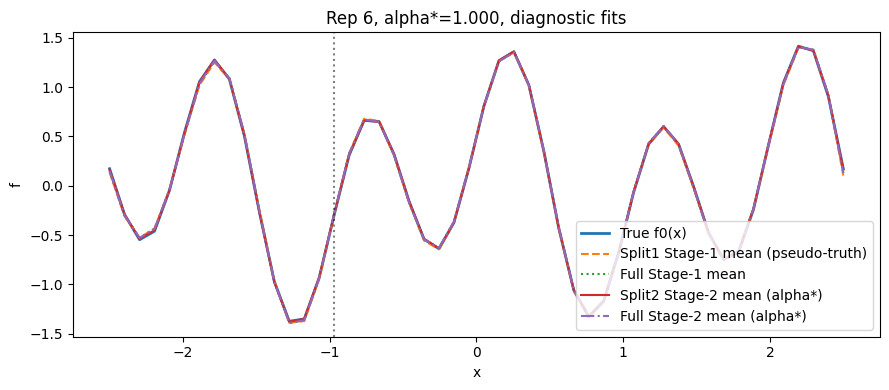

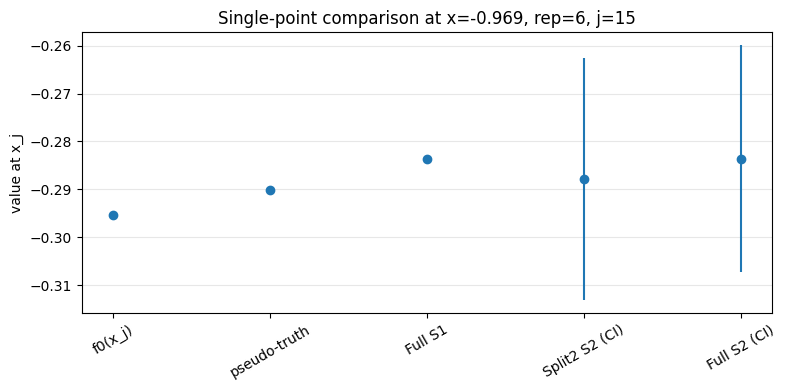

In [2]:
# 单 rep・单点 debug：calibration vs double-check 对比

import os, math, time
from dataclasses import dataclass
from contextlib import ExitStack

import torch
import gpytorch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ----------------- 配置 & 路径 -----------------

@dataclass
class CFG:
    # data
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # model / training
    use_fp64: bool = True
    use_ciq: bool = False
    inducing_points: int = 50
    stage1_epochs: int = 2000
    stage2_epochs: int = 800
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13           # base seed; per rep: seed + rep_id

    # early stopping for Stage-1
    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4

    # experiment
    ci_level: float = 0.95

    # logging
    log_epoch: bool = False
    log_every: int = 10


cfg = CFG()

# ---- 你要改的地方：本地结果路径 & 目标 rep / j ----
CALIB_DIR = r"C:\Users\yangy\reproduction\pointwise_two_split_R\results"
DOUBLECHECK_DIR = r"C:\Users\yangy\reproduction\new_results\doublecheck"

TARGET_REP = 6   # 例如 6、31、57 这些“坏的” rep
TARGET_J   = 15  # 在那个 rep 里挑一个 cov_calib≈1 但 cov_indicator=0 的 j

# ----------------- 工具函数 -----------------

def now():
    return time.strftime("%H:%M:%S")

def log(msg):
    print(f"[{now()}] {msg}", flush=True)

def gpu_mem_mb():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1e6
    return 0.0

def has_setting(name: str) -> bool:
    return hasattr(gpytorch.settings, name)

def ciq_context():
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

# 真 f0
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

# 1D LHS-like
def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

# ----------------- 模型 & 训练 -----------------

class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def freeze_all_params(model, likelihood):
    for p in model.parameters():
        p.requires_grad_(False)
    for p in likelihood.parameters():
        p.requires_grad_(False)


def pick_covariance_params_svgp(model):
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True)
                trainables.append(p)
                names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar", "variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor", "_variational_distribution.chol_covar",
            "raw_covar", "chol_factor", "covar_factor", "variational_stddev", "raw_var",
            "qchol", "q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True)
                trainables.append(p)
                names.append(n)
    return trainables, names


def stage1_train(model, likelihood, x_train_std, y_train, lr, epochs, jitter,
                 batch_size, early_stop_patience, early_stop_min_delta,
                 log_epoch=False, log_every=10):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(
        likelihood, model, num_data=N, beta=1.0
    )

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(
        TensorDataset(x_train_std, y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    model.train()
    likelihood.train()
    neg_elbo_hist = []
    best_loss = float("inf")
    best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item())
                n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss = avg_loss
                best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if log_epoch and (ep % log_every == 0 or ep == 1 or ep == epochs):
                log(f"[S1] epoch {ep:04d}/{epochs} | -ELBO={avg_loss:.6f} "
                    f"(best {best_loss:.6f}@{best_epoch})")

            if patience >= early_stop_patience:
                break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval()
    likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss


def stage2_train_cov_only(model, likelihood, x_train_std, y_train, beta, lr,
                          epochs, jitter, batch_size):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."

    mll = gpytorch.mlls.VariationalELBO(
        likelihood, model, num_data=N, beta=beta
    )
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(
        TensorDataset(x_train_std, y_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    model.train()
    likelihood.train()
    neg_elbo_hist = []
    best_loss = float("inf")
    best_epoch = 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item())
                n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_epoch = ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval()
    likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names

# ----------------- 主调试流程 -----------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

log(f"Device: {device}, dtype: {torch.get_default_dtype()}")

# 1) 从 doublecheck 里读这个 rep / j 的记录
dc_path = os.path.join(DOUBLECHECK_DIR, f"rep_{TARGET_REP:03d}_doublecheck.csv")
dc_df = pd.read_csv(dc_path)
row = dc_df.iloc[TARGET_J]

x_j = float(row["x"])
alpha_star = float(row["alpha_star"])
cov_indicator = float(row["cov_indicator"])
cov_calib = float(row["cov_at_alpha_star_calib"])

log(f"[Doublecheck CSV] rep={TARGET_REP}, j={TARGET_J}, x={x_j:.6f}, "
    f"alpha_star={alpha_star:.4f}, cov_ind={cov_indicator}, cov_calib={cov_calib:.3f}")

# 2) 重建这一 rep 的数据、split、Stage-1 模型

seed_r = cfg.seed + TARGET_REP
torch.manual_seed(seed_r)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_r)

gen = torch.Generator(device=device).manual_seed(seed_r)

# 训练 + 测试
x_train_raw = make_stratified_points_1d(
    n=cfg.n_train, low=cfg.train_low, high=cfg.train_high,
    generator=gen, device=device, dtype=torch.get_default_dtype()
)
x_test_raw = torch.linspace(
    cfg.test_low, cfg.test_high, cfg.n_test,
    device=device, dtype=torch.get_default_dtype()
).unsqueeze(1)

y_train_full = f0(x_train_raw).squeeze(-1)
y_test_true = f0(x_test_raw).squeeze(-1)

# 对称线性标准化
mid = torch.tensor(
    [(cfg.train_low + cfg.train_high) / 2.0],
    device=device, dtype=torch.get_default_dtype()
)
half = torch.tensor(
    [(cfg.train_high - cfg.train_low) / 2.0],
    device=device, dtype=torch.get_default_dtype()
).clamp_min(1e-12)

def to_std(x_raw):
    return (x_raw - mid) / half

x_train_std_full = to_std(x_train_raw)
x_test_std = to_std(x_test_raw)

# inducing points
Z_raw = torch.linspace(
    cfg.train_low, cfg.train_high, cfg.inducing_points,
    device=device, dtype=torch.get_default_dtype()
).unsqueeze(1)
Z_std = to_std(Z_raw)

log(f"Training set reconstructed: n_train={x_train_raw.shape[0]}")
log(f"Test grid first/last x: {float(x_test_raw[0]):.3f}, {float(x_test_raw[-1]):.3f}")

# 两半 split
n_train = cfg.n_train
perm = torch.randperm(n_train, device=device)
half_n = n_train // 2
split1_idx = perm[:half_n]
split2_idx = perm[half_n:]

x_s1_std = x_train_std_full[split1_idx]
y_s1 = y_train_full[split1_idx]
x_s2_std = x_train_std_full[split2_idx]
y_s2 = y_train_full[split2_idx]

# ---- Split1 Stage-1 -> pseudo-truth ----
model_s1 = SVGPModel(Z_std.clone().contiguous()).to(device=device)
lik_s1 = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
with torch.no_grad():
    model_s1.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_s1.covar_module.outputscale.fill_(1.0)
    lik_s1.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
lik_s1.noise_covar.raw_noise.requires_grad_(False)

log("[Split1] Stage-1 training...")
with (ciq_context() if cfg.use_ciq else ExitStack()):
    s1_hist_split1, best_ep_s1_1, best_loss_s1_1 = stage1_train(
        model_s1, lik_s1, x_s1_std, y_s1,
        lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
        batch_size=cfg.batch_size,
        early_stop_patience=cfg.early_stop_patience,
        early_stop_min_delta=cfg.early_stop_min_delta,
        log_epoch=False, log_every=cfg.log_every
    )

with torch.no_grad():
    mu_truth = model_s1(x_test_std).mean

log(f"[Split1] best -ELBO={best_loss_s1_1:.6f} at epoch {best_ep_s1_1}")

# ---- Split2 Stage-1 base ----
model_s2 = SVGPModel(Z_std.clone().contiguous()).to(device=device)
lik_s2 = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
with torch.no_grad():
    model_s2.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_s2.covar_module.outputscale.fill_(1.0)
    lik_s2.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
lik_s2.noise_covar.raw_noise.requires_grad_(False)

log("[Split2] Stage-1 training...")
with (ciq_context() if cfg.use_ciq else ExitStack()):
    s1_hist_split2, best_ep_s1_2, best_loss_s1_2 = stage1_train(
        model_s2, lik_s2, x_s2_std, y_s2,
        lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
        batch_size=cfg.batch_size,
        early_stop_patience=cfg.early_stop_patience,
        early_stop_min_delta=cfg.early_stop_min_delta,
        log_epoch=False, log_every=cfg.log_every
    )

base_model_s2_sd = clone_state_dict(model_s2.state_dict())
base_lik_s2_sd = clone_state_dict(lik_s2.state_dict())
with torch.no_grad():
    mu_split2_s1 = model_s2(x_test_std).mean

log(f"[Split2] best -ELBO={best_loss_s1_2:.6f} at epoch {best_ep_s1_2}")

# ---- Full Stage-1 ----
model_full = SVGPModel(Z_std.clone().contiguous()).to(device=device)
lik_full = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
with torch.no_grad():
    model_full.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_full.covar_module.outputscale.fill_(1.0)
    lik_full.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
lik_full.noise_covar.raw_noise.requires_grad_(False)

log("[Full] Stage-1 training...")
with (ciq_context() if cfg.use_ciq else ExitStack()):
    s1_hist_full, best_ep_s1_f, best_loss_s1_f = stage1_train(
        model_full, lik_full, x_train_std_full, y_train_full,
        lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
        batch_size=cfg.batch_size,
        early_stop_patience=cfg.early_stop_patience,
        early_stop_min_delta=cfg.early_stop_min_delta,
        log_epoch=False, log_every=cfg.log_every
    )

with torch.no_grad():
    mu_full_s1 = model_full(x_test_std).mean

log(f"[Full] best -ELBO={best_loss_s1_f:.6f} at epoch {best_ep_s1_f}")

# 3) Stage-2 in calibration world: split2 + alpha_star, 全数据一次（代表性）
beta_star = 1.0 / alpha_star
log(f"[Split2] Stage-2 with alpha*={alpha_star:.4f} (beta={beta_star:.4f})")

model_s2.load_state_dict(base_model_s2_sd)
lik_s2.load_state_dict(base_lik_s2_sd)
with (ciq_context() if cfg.use_ciq else ExitStack()):
    s2_hist_split2, best_ep_s2_2, best_loss_s2_2, _ = stage2_train_cov_only(
        model_s2, lik_s2, x_s2_std, y_s2,
        beta=beta_star, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
        jitter=cfg.jitter, batch_size=cfg.batch_size
    )

with torch.no_grad():
    pred_split2_s2 = model_s2(x_test_std)
    mu_split2_s2 = pred_split2_s2.mean
    std_split2_s2 = pred_split2_s2.variance.sqrt().clamp_min(1e-12)

log(f"[Split2] Stage-2 best -ELBO={best_loss_s2_2:.6f} at epoch {best_ep_s2_2}")

# 4) Stage-2 in double-check world: full data + alpha_star
log(f"[Full] Stage-2 with alpha*={alpha_star:.4f} (beta={beta_star:.4f})")

model_full_s2 = SVGPModel(Z_std.clone().contiguous()).to(device=device)
lik_full_s2 = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
with torch.no_grad():
    model_full_s2.covar_module.base_kernel.lengthscale.fill_(1.0)
    model_full_s2.covar_module.outputscale.fill_(1.0)
    lik_full_s2.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
lik_full_s2.noise_covar.raw_noise.requires_grad_(False)

# 先加载 full Stage-1 checkpoint
model_full_s2.load_state_dict(clone_state_dict(model_full.state_dict()))
lik_full_s2.load_state_dict(clone_state_dict(lik_full.state_dict()))

with (ciq_context() if cfg.use_ciq else ExitStack()):
    s2_hist_full, best_ep_s2_f, best_loss_s2_f, _ = stage2_train_cov_only(
        model_full_s2, lik_full_s2, x_train_std_full, y_train_full,
        beta=beta_star, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
        jitter=cfg.jitter, batch_size=cfg.batch_size
    )

with torch.no_grad():
    pred_full_s2 = model_full_s2(x_test_std)
    mu_full_s2 = pred_full_s2.mean
    std_full_s2 = pred_full_s2.variance.sqrt().clamp_min(1e-12)

log(f"[Full] Stage-2 best -ELBO={best_loss_s2_f:.6f} at epoch {best_ep_s2_f}")

# 5) 单点 j 的详细数值 & 覆盖情况

idx_j = TARGET_J
idx_tensor = torch.tensor([idx_j], device=device, dtype=torch.long)

z_ci = 1.96  # 95% CI

f0_j = y_test_true[idx_tensor][0].item()
mu_truth_j = mu_truth[idx_tensor][0].item()
mu_full_s1_j = mu_full_s1[idx_tensor][0].item()
mu_split2_s2_j = mu_split2_s2[idx_tensor][0].item()
std_split2_s2_j = std_split2_s2[idx_tensor][0].item()
mu_full_s2_j = mu_full_s2[idx_tensor][0].item()
std_full_s2_j = std_full_s2[idx_tensor][0].item()

ci_split2 = (mu_split2_s2_j - z_ci * std_split2_s2_j,
             mu_split2_s2_j + z_ci * std_split2_s2_j)
ci_full   = (mu_full_s2_j - z_ci * std_full_s2_j,
             mu_full_s2_j + z_ci * std_full_s2_j)

def in_ci(val, ci):
    return (val >= ci[0]) and (val <= ci[1])

log("\n=========== Single-point diagnostics ===========")
log(f"rep={TARGET_REP}, j={TARGET_J}, x_j={x_j:.6f}, alpha*={alpha_star:.4f}")
log(f"  f0(x_j)            = {f0_j:.6f}")
log(f"  pseudo-truth mu_s1_split1(x_j) = {mu_truth_j:.6f}")
log(f"  full Stage-1 mu_full(x_j)      = {mu_full_s1_j:.6f}")

log("\n[Calibration world: split2 Stage-2 (no bootstrap, full split2 data)]")
log(f"  mu_split2_s2(x_j)   = {mu_split2_s2_j:.6f}")
log(f"  std_split2_s2(x_j)  = {std_split2_s2_j:.6f}")
log(f"  CI_split2           = [{ci_split2[0]:.6f}, {ci_split2[1]:.6f}]")
log(f"  CI_split2 covers pseudo-truth? {in_ci(mu_truth_j, ci_split2)}")
log(f"  CI_split2 covers f0?           {in_ci(f0_j, ci_split2)}")

log("\n[Double-check world: full Stage-2]")
log(f"  mu_full_s2(x_j)     = {mu_full_s2_j:.6f}")
log(f"  std_full_s2(x_j)    = {std_full_s2_j:.6f}")
log(f"  CI_full             = [{ci_full[0]:.6f}, {ci_full[1]:.6f}]")
log(f"  CI_full covers pseudo-truth?   {in_ci(mu_truth_j, ci_full)}")
log(f"  CI_full covers f0?             {in_ci(f0_j, ci_full)}")

# 6) 画图：整个区间的 fit 对比 & 单点误差条

x_axis = x_test_raw.squeeze(-1).cpu().numpy()
f0_np = y_test_true.cpu().numpy()
mu_truth_np = mu_truth.cpu().numpy()
mu_full_s1_np = mu_full_s1.cpu().numpy()
mu_split2_s2_np = mu_split2_s2.cpu().numpy()
mu_full_s2_np = mu_full_s2.cpu().numpy()

plt.figure(figsize=(9,4))
plt.plot(x_axis, f0_np, label="True f0(x)", linewidth=2)
plt.plot(x_axis, mu_truth_np, "--", label="Split1 Stage-1 mean (pseudo-truth)")
plt.plot(x_axis, mu_full_s1_np, ":", label="Full Stage-1 mean")
plt.plot(x_axis, mu_split2_s2_np, "-", label="Split2 Stage-2 mean (alpha*)")
plt.plot(x_axis, mu_full_s2_np, "-.", label="Full Stage-2 mean (alpha*)")
plt.axvline(x_j, color="k", linestyle=":", alpha=0.5)
plt.title(f"Rep {TARGET_REP}, alpha*={alpha_star:.3f}, diagnostic fits")
plt.xlabel("x")
plt.ylabel("f")
plt.legend()
plt.tight_layout()
plt.show()

# 单点误差条图
labels = ["f0(x_j)", "pseudo-truth", "Full S1", "Split2 S2 (CI)", "Full S2 (CI)"]
x_pos = np.arange(len(labels))
y_vals = [
    f0_j,
    mu_truth_j,
    mu_full_s1_j,
    mu_split2_s2_j,
    mu_full_s2_j,
]
y_err = [
    0.0,
    0.0,
    0.0,
    z_ci * std_split2_s2_j,
    z_ci * std_full_s2_j,
]

plt.figure(figsize=(8,4))
plt.errorbar(x_pos, y_vals, yerr=y_err, fmt="o")
plt.xticks(x_pos, labels, rotation=30)
plt.ylabel("value at x_j")
plt.title(f"Single-point comparison at x={x_j:.3f}, rep={TARGET_REP}, j={TARGET_J}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
